#基础CNN


复用肺炎模型代码

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 检查GPU是否可用
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir("/content/drive/My Drive/Biomedical")
dataset_path = "/content/drive/My Drive/Biomedical/ISIC/Skin Cancer"

Using device: cuda
Mounted at /content/drive


In [2]:
def analyze_csv_structure(csv_path, images_dir):
    df = pd.read_csv(csv_path)

    print(f"CSV形状: {df.shape}")
    print(f"列名: {list(df.columns)}")
    print("\n前5行:")
    print(df.head())

    print("\n基本信息:")
    print(df.info())

    print("\n数值列统计:")
    print(df.describe())

    return df

csv_path = "/content/drive/My Drive/Biomedical/ISIC/HAM10000_metadata.csv"
images_dir = "/content/drive/My Drive/Biomedical/ISIC/Skin Cancer/Skin Cancer"
df = analyze_csv_structure(csv_path, images_dir)

CSV形状: (10015, 7)
列名: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

前5行:
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear

基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  obj


=== 标签分布分析 (基于列: dx) ===
标签分布:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3701511738.py:31: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missi

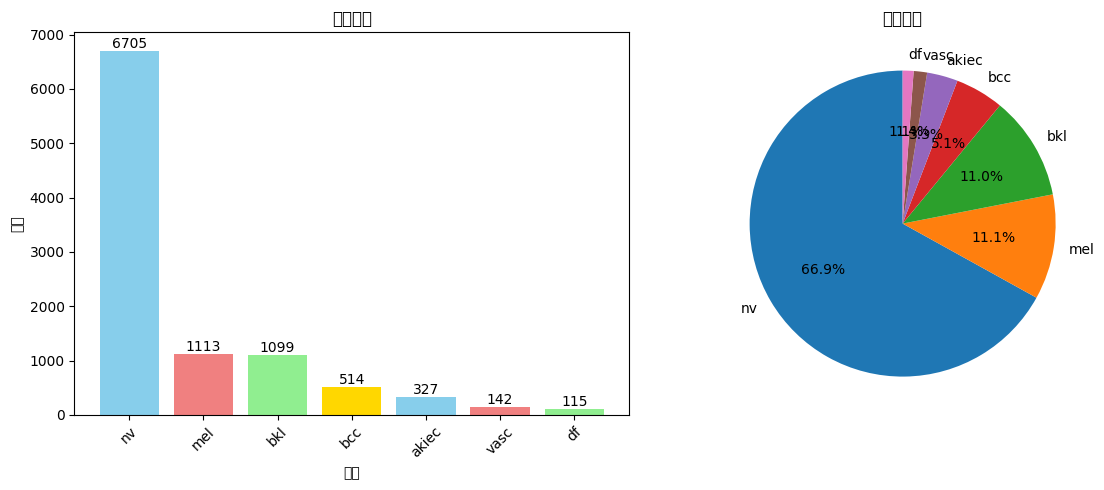


不平衡分析:
  不平衡比例: 58.3:1
  多数类: nv (6705个)
  少数类: df (115个)


In [3]:
def analyze_labels_distribution(df, label_column):
    """分析标签分布"""
    print(f"\n=== 标签分布分析 (基于列: {label_column}) ===")

    # 标签统计
    label_counts = df[label_column].value_counts()
    print("标签分布:")
    print(label_counts)

    # 可视化
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    bars = plt.bar(label_counts.index.astype(str), label_counts.values,
                   color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
    plt.title('标签分布')
    plt.xlabel('标签')
    plt.ylabel('数量')
    plt.xticks(rotation=45)

    # 在柱子上添加数值
    for bar, count in zip(bars, label_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{count}', ha='center', va='bottom')

    plt.subplot(1, 2, 2)
    plt.pie(label_counts.values, labels=label_counts.index.astype(str),
            autopct='%1.1f%%', startangle=90)
    plt.title('标签比例')

    plt.tight_layout()
    plt.show()

    # 不平衡分析
    max_count = label_counts.max()
    min_count = label_counts.min()
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    print(f"\n不平衡分析:")
    print(f"  不平衡比例: {imbalance_ratio:.1f}:1")
    print(f"  多数类: {label_counts.idxmax()} ({max_count}个)")
    print(f"  少数类: {label_counts.idxmin()} ({min_count}个)")

    return label_counts

label_column = "dx"  # 替换为你的标签列名
label_counts = analyze_labels_distribution(df, label_column)

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 先定义数据集类
class CSVSkinDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None, image_id_col="image_id", label_col="dx"):
        self.df = pd.read_csv(csv_path)
        self.images_dir = images_dir
        self.transform = transform
        self.image_id_col = image_id_col
        self.label_col = label_col

        # 创建标签映射
        self.classes = sorted(self.df[label_col].unique())
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.idx_to_class = {i: cls_name for cls_name, i in self.class_to_idx.items()}

        # 过滤有效样本
        self.valid_samples = []
        for idx, row in self.df.iterrows():
            image_path = os.path.join(self.images_dir, f"{row[image_id_col]}.jpg")  # 根据实际扩展名修改
            if os.path.exists(image_path):
                self.valid_samples.append((image_path, row[label_col]))

        print(f"数据集大小: {len(self.valid_samples)}")

    def __len__(self):
        return len(self.valid_samples)

    def __getitem__(self, idx):
        img_path, label = self.valid_samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label_idx = self.class_to_idx[label]
        return image, label_idx

# 创建数据集
full_dataset = CSVSkinDataset(
    csv_path=csv_path,
    images_dir=images_dir,
    transform=train_transforms,
    image_id_col="image_id",
    label_col="dx"
)

print(f"完整数据集大小: {len(full_dataset)}")
print(f"类别: {full_dataset.classes}")

数据集大小: 9128
完整数据集大小: 9128
类别: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [5]:
from torch.utils.data import random_split
def split_dataset(dataset, train_ratio=0.8):
    """分割数据集"""
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # 为验证集设置不同的变换
    val_dataset.dataset = type(dataset)(
        csv_path=csv_path,
        images_dir=images_dir,
        transform=val_transforms,
        image_id_col="image_id",
        label_col="dx"
    )

    return train_dataset, val_dataset

train_dataset, val_dataset = split_dataset(full_dataset)
print(f"训练集: {len(train_dataset)} 张图片")
print(f"验证集: {len(val_dataset)} 张图片")

数据集大小: 9128
训练集: 7302 张图片
验证集: 1826 张图片


In [6]:
from torch.utils.data import WeightedRandomSampler
from collections import Counter
from PIL import Image
from torch.utils.data import DataLoader

print("使用加权损失函数代替平衡采样器...")

def calculate_class_weights(dataset):
    print("计算类别权重...")

    if hasattr(dataset, 'dataset'):
        original_dataset = dataset.dataset
        # 直接从CSV计算，避免读取图片
        label_counts = original_dataset.df[original_dataset.label_col].value_counts()
    else:
        # 备用方法：采样计算
        labels = []
        for i in range(min(1000, len(dataset))):
            _, label = dataset[i]
            labels.append(label)
        label_counts = pd.Series(labels).value_counts()

    print("类别分布:")
    for class_name, count in label_counts.items():
        print(f"  {class_name}: {count}")

    # 计算权重
    total = label_counts.sum()
    num_classes = len(label_counts)
    weights = [total / (num_classes * count) for count in label_counts.values]
    weights_tensor = torch.FloatTensor(weights).to(device)

    print("类别权重:", {class_name: f"{weight:.2f}" for class_name, weight in zip(label_counts.index, weights)})
    return weights_tensor

# 计算权重
class_weights = calculate_class_weights(train_dataset)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 使用简单的数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("数据加载器创建完成")
print(f"训练批次: {len(train_loader)}")
print(f"验证批次: {len(val_loader)}")

使用加权损失函数代替平衡采样器...
计算类别权重...
类别分布:
  nv: 6705
  mel: 1113
  bkl: 1099
  bcc: 514
  akiec: 327
  vasc: 142
  df: 115
类别权重: {'nv': '0.21', 'mel': '1.29', 'bkl': '1.30', 'bcc': '2.78', 'akiec': '4.38', 'vasc': '10.08', 'df': '12.44'}
数据加载器创建完成
训练批次: 229
验证批次: 58


In [7]:
# 测试单张图片读取
print("🧪 测试单张图片读取...")
try:
    # 直接从原始数据集测试
    original_dataset = train_dataset.dataset

    start_time = time.time()
    image, label = original_dataset[0]  # 测试第一张图片
    print(f"✅ 单张图片读取成功!")
    print(f"   图像形状: {image.shape}")
    print(f"   标签: {label} -> {original_dataset.idx_to_class[label]}")
    print(f"   读取时间: {time.time()-start_time:.2f}秒")

except Exception as e:
    print(f"❌ 图片读取失败: {e}")
    import traceback
    traceback.print_exc()

🧪 测试单张图片读取...
❌ 图片读取失败: name 'time' is not defined


Traceback (most recent call last):
  File "/tmp/ipython-input-598502681.py", line 7, in <cell line: 0>
    start_time = time.time()
                 ^^^^
NameError: name 'time' is not defined. Did you forget to import 'time'


In [8]:
# 创建模型
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(full_dataset.classes))
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"模型: EfficientNet-B0")
print(f"类别数: {len(full_dataset.classes)}")
print(f"训练样本: {len(train_dataset)}")
print(f"验证样本: {len(val_dataset)}")

# 训练循环
model.train()
train_losses = []
val_accuracies = []

for epoch in range(5):  # 先训练5个epoch
    epoch_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # 计算训练准确率
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        if i % 20 == 0:
            print(f"Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.4f}")

    # 验证
    model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1} 完成:")
    print(f"  平均损失: {avg_loss:.4f}")
    print(f"  训练准确率: {train_accuracy:.2f}%")
    print(f"  验证准确率: {val_accuracy:.2f}%")
    print("-" * 50)

print("训练完成")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 70.0MB/s]


模型: EfficientNet-B0
类别数: 7
训练样本: 7302
验证样本: 1826
Epoch 1, Batch 0, Loss: 2.1657
Epoch 1, Batch 20, Loss: 1.4360
Epoch 1, Batch 40, Loss: 0.8012
Epoch 1, Batch 60, Loss: 0.5296
Epoch 1, Batch 80, Loss: 0.6742
Epoch 1, Batch 100, Loss: 0.2987
Epoch 1, Batch 120, Loss: 0.4189
Epoch 1, Batch 140, Loss: 0.3462
Epoch 1, Batch 160, Loss: 0.1683
Epoch 1, Batch 180, Loss: 0.2335
Epoch 1, Batch 200, Loss: 0.3125
Epoch 1, Batch 220, Loss: 0.2860
Epoch 1 完成:
  平均损失: 0.5488
  训练准确率: 66.52%
  验证准确率: 71.85%
--------------------------------------------------
Epoch 2, Batch 0, Loss: 0.3486
Epoch 2, Batch 20, Loss: 0.2210
Epoch 2, Batch 40, Loss: 0.3908
Epoch 2, Batch 60, Loss: 0.1093
Epoch 2, Batch 80, Loss: 0.3092
Epoch 2, Batch 100, Loss: 0.1906
Epoch 2, Batch 120, Loss: 0.2230
Epoch 2, Batch 140, Loss: 0.1757
Epoch 2, Batch 160, Loss: 0.3278
Epoch 2, Batch 180, Loss: 0.2068
Epoch 2, Batch 200, Loss: 0.3439
Epoch 2, Batch 220, Loss: 0.1715
Epoch 2 完成:
  平均损失: 0.2692
  训练准确率: 73.38%
  验证准确率: 76.12%
--

/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2530528400.py:18: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missi

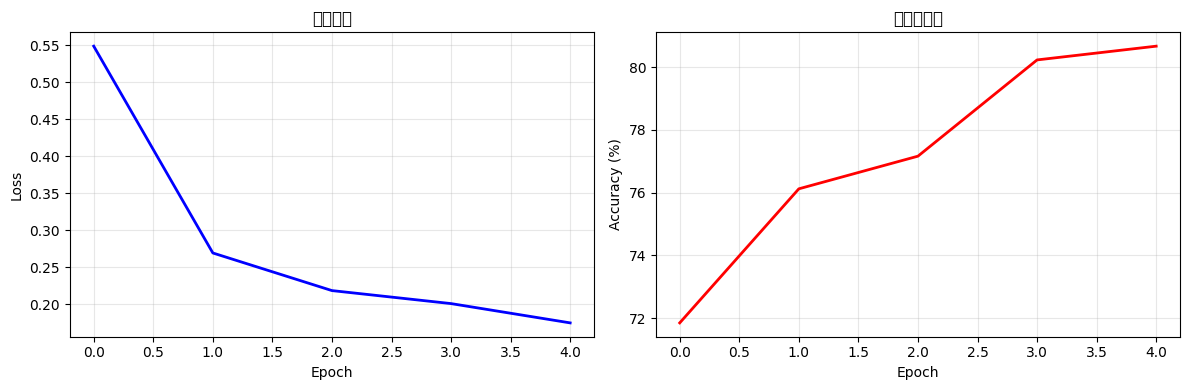

最终验证准确率: 80.67%


In [9]:
# 绘制训练曲线
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', linewidth=2)
plt.title('训练损失')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(val_accuracies, 'r-', linewidth=2)
plt.title('验证准确率')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最终验证准确率: {val_accuracies[-1]:.2f}%")

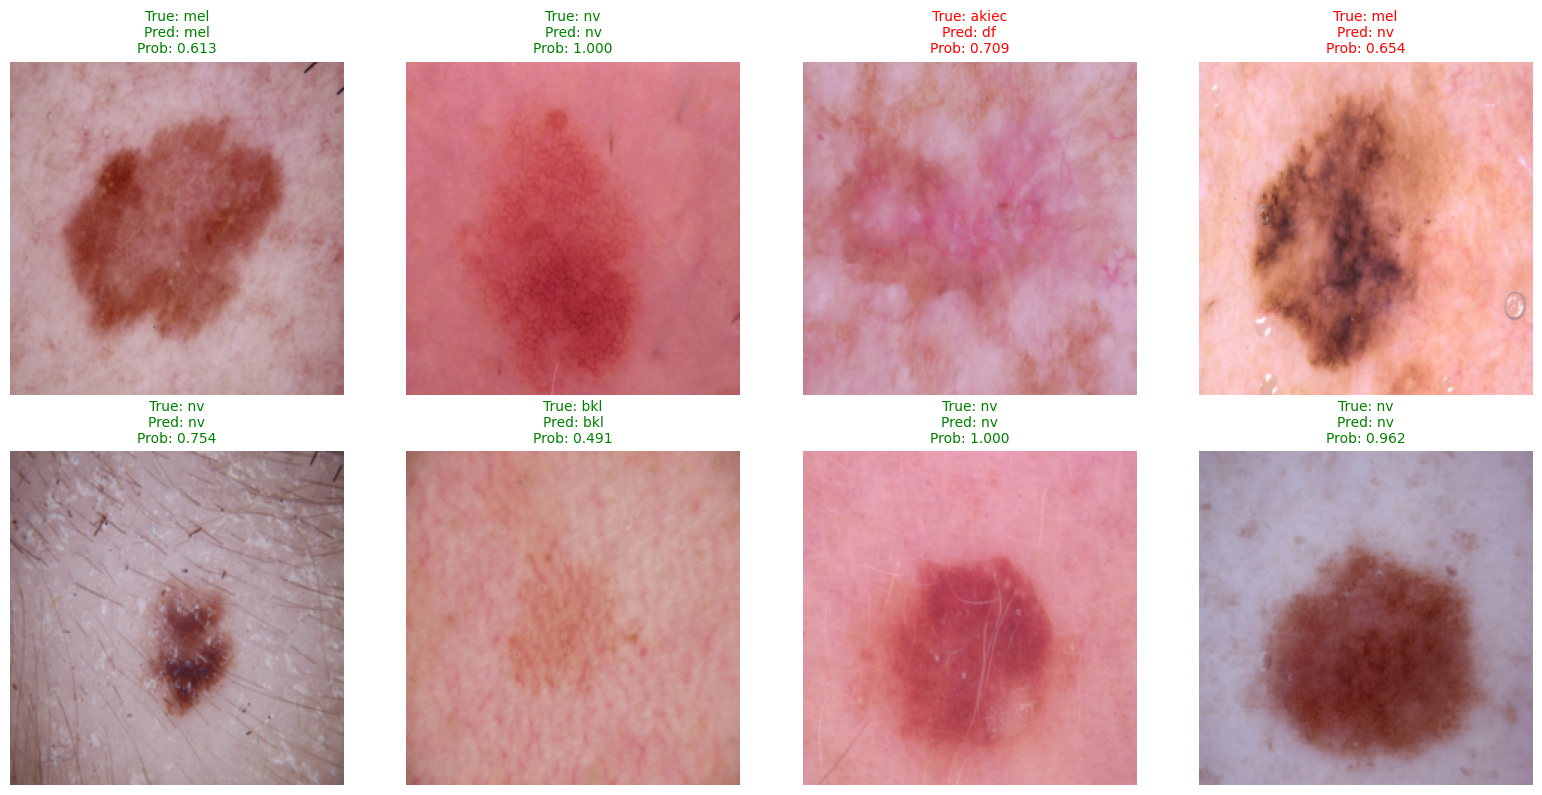

In [10]:
# 测试模型预测
def test_predictions(model, val_loader, class_names):
    """测试模型预测效果"""
    model.eval()

    # 获取一个batch
    images, labels = next(iter(val_loader))

    with torch.no_grad():
        images = images.to(device)
        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)

    # 可视化结果
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i in range(min(8, len(images))):
        img = images[i].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)

        axes[i].imshow(img.permute(1, 2, 0))

        true_label = class_names[labels[i].item()]
        pred_label = class_names[predictions[i].item()]
        prob = probabilities[i][predictions[i]].item()

        color = 'green' if true_label == pred_label else 'red'
        title = f'True: {true_label}\nPred: {pred_label}\nProb: {prob:.3f}'
        axes[i].set_title(title, color=color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# 运行测试
test_predictions(model, val_loader, full_dataset.classes)